# MATLAB vs Python LVGP — head-to-head on the 1-D problem (branin_hetero)

Focused comparison of the **four LVGP models** — the two MATLAB engines and their faithful Python
(native numpy) ports — on the one-dimensional test case. Everything else in the benchmark is held out
so the plots isolate *MATLAB code vs Python code*.

| | homoscedastic (noise-blind) | heteroscedastic (noise-aware) |
|---|---|---|
| **MATLAB** | `standard_LVGP` | `heter_LVGP` |
| **Python** | `lvgp_native` | `heter_lvgp_native` |

Same shared initial design per seed (CRN); BO *iteration* noise differs across engines, so read the
convergence/coverage as **distributional**, not cell-by-cell.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, matplotlib.pyplot as plt, glob, re
import scipy.io as sio
from utils import problems as P
import utils.results as R
from utils.results import GridResults, facet, acquisition_facet, heatmaps_by_function, final_regret_table

LVGP4 = ["standard_LVGP", "lvgp_native", "heter_LVGP", "heter_lvgp_native"]
R.MODEL_ORDER = LVGP4                       # colour/legend order in the built-in plots

_full = GridResults.load('../results')
grid  = GridResults(_full.root, [r for r in _full.runs
                                 if r["problem"] == "branin_hetero" and r["model"] in LVGP4])
print("models :", grid.models())
for m in LVGP4:
    print(f"  {m:20s} {sum(r['model']==m for r in grid.runs):4d} cells")

models : ['heter_LVGP', 'heter_lvgp_native', 'lvgp_native', 'standard_LVGP']
  standard_LVGP         180 cells
  lvgp_native            67 cells
  heter_LVGP            360 cells
  heter_lvgp_native     133 cells


## Toggles

In [2]:
FUNC   = "branin_hetero"
N_REP  = 10
GROUND_TRUTH = True
CENTER = "median"
LVGP4  = ["standard_LVGP", "lvgp_native", "heter_LVGP", "heter_lvgp_native"]
def engine(m): return "MATLAB" if m in ("standard_LVGP", "heter_LVGP") else "Python"

## 1. Results — final regret table (problem × model)
Lower is better. Read across: each MATLAB column vs its Python port.

In [3]:
final_regret_table(grid, acf="ei", param=float("nan"), n_rep=N_REP)

,Heteroscedastic LVGP,Hetero LVGP (native),LVGP (native),Standard LVGP
branin_hetero,0.080 ± 0.058,0.104 ± 0.055,0.010 ± 0.018,0.002 ± 0.008


## 2. Computing time — MATLAB vs Python

Mean wall-clock per cell and **per BO iteration**.

> **Caveat:** the MATLAB cells were produced on `vision` (18-core, shared/contended by the live sweep
> and other users), the Python native cells on `aida` (idle). So the raw ratio conflates *model* and
> *machine*; the honest read is "Python is dramatically cheaper per iteration", with the exact factor
> partly machine-dependent.

model                 engine   cells     s/cell   s/iter
standard_LVGP         MATLAB     180      676.4    13.53
lvgp_native           Python      67      282.6     5.65
heter_LVGP            MATLAB     360      750.3    15.01
heter_lvgp_native     Python     133      213.0     4.26


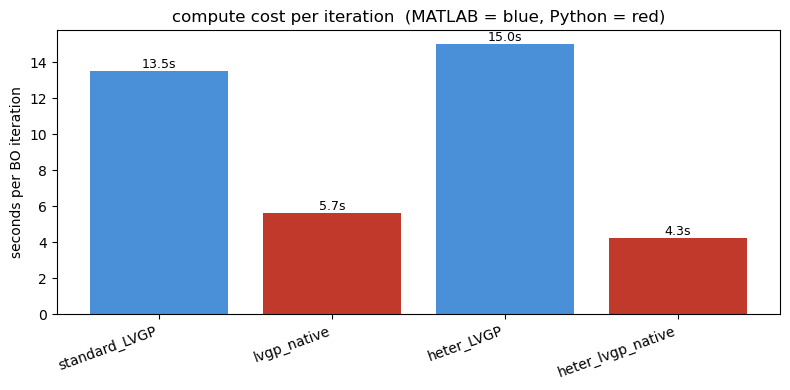

lvgp_native: ~2x faster/iter than standard_LVGP  (machine-confounded; see caveat)
heter_lvgp_native: ~4x faster/iter than heter_LVGP  (machine-confounded; see caveat)


In [4]:
rt = {}
for m in LVGP4:
    runs = [r for r in grid.runs if r["model"] == m and r.get("runtime")]
    if not runs: continue
    t  = np.array([float(r["runtime"]) for r in runs])
    it = np.array([float(r.get("num_iter", 50)) for r in runs])
    rt[m] = (t.mean(), (t / it).mean(), len(runs))
print(f"{'model':22s}{'engine':8s}{'cells':>6s}{'s/cell':>11s}{'s/iter':>9s}")
for m in LVGP4:
    if m in rt:
        print(f"{m:22s}{engine(m):8s}{rt[m][2]:6d}{rt[m][0]:11.1f}{rt[m][1]:9.2f}")
present = [m for m in LVGP4 if m in rt]
fig, ax = plt.subplots(figsize=(8, 4))
cols = ["#4a90d9" if engine(m) == "MATLAB" else "#c0392b" for m in present]
ax.bar(range(len(present)), [rt[m][1] for m in present], color=cols)
for i, m in enumerate(present):
    ax.text(i, rt[m][1], f"{rt[m][1]:.1f}s", ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(present))); ax.set_xticklabels(present, rotation=20, ha="right")
ax.set_ylabel("seconds per BO iteration")
ax.set_title("compute cost per iteration  (MATLAB = blue, Python = red)")
plt.tight_layout(); plt.show()
for mm, pp in [("standard_LVGP", "lvgp_native"), ("heter_LVGP", "heter_lvgp_native")]:
    if mm in rt and pp in rt:
        print(f"{pp}: ~{rt[mm][1]/rt[pp][1]:.0f}x faster/iter than {mm}  (machine-confounded; see caveat)")

## 3. Convergence — REGRET (value − f*)
The 4 LVGP models overlaid, median ± IQR across seeds.

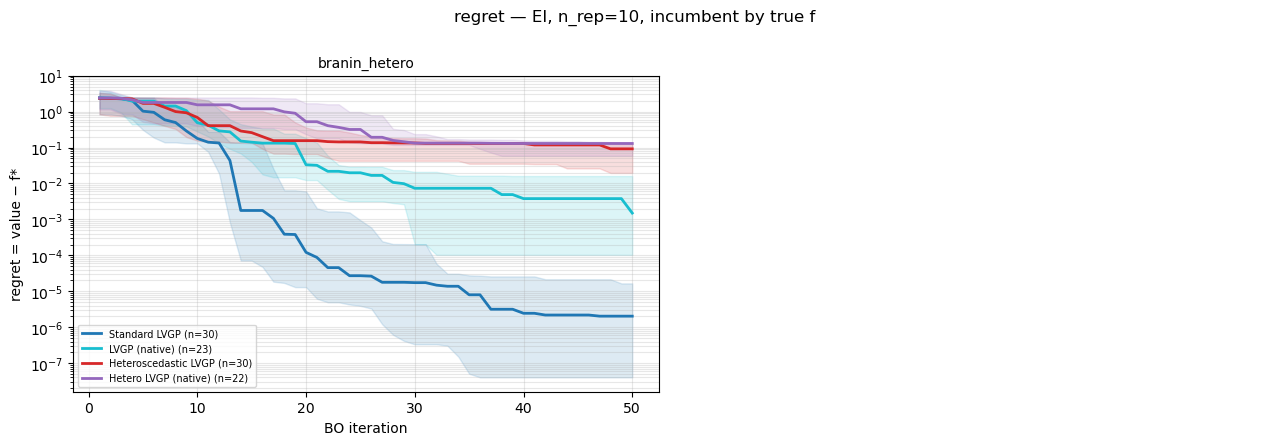

In [5]:
facet(grid, "regret", functions=[FUNC], acf="ei", n_rep=N_REP,
      ground_truth=GROUND_TRUTH, center=CENTER);

## 4. Convergence — VALUE (with f* as a horizontal line)

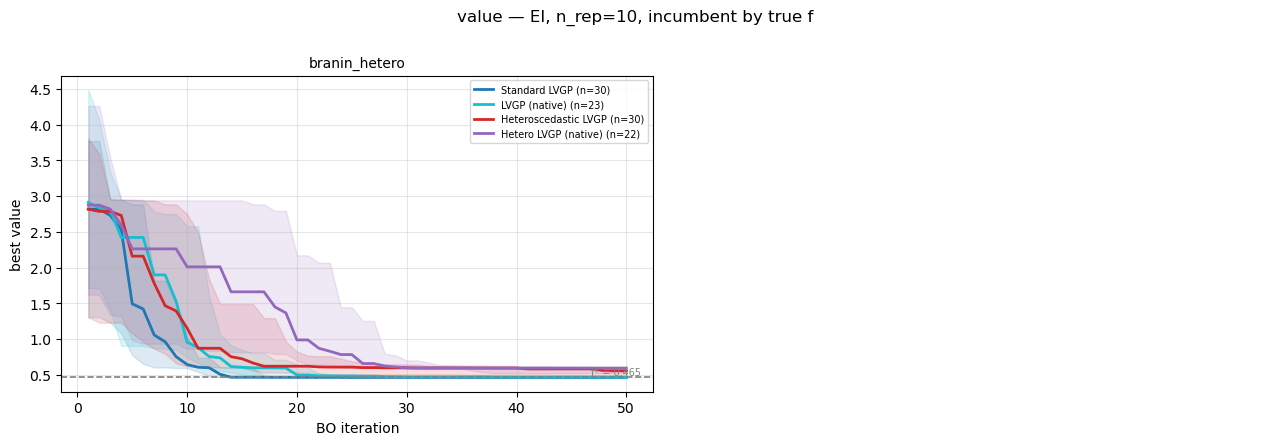

In [6]:
facet(grid, "value", functions=[FUNC], acf="ei", n_rep=N_REP,
      ground_truth=GROUND_TRUTH, center=CENTER);

## 5. Noise σ² at the incumbent best design

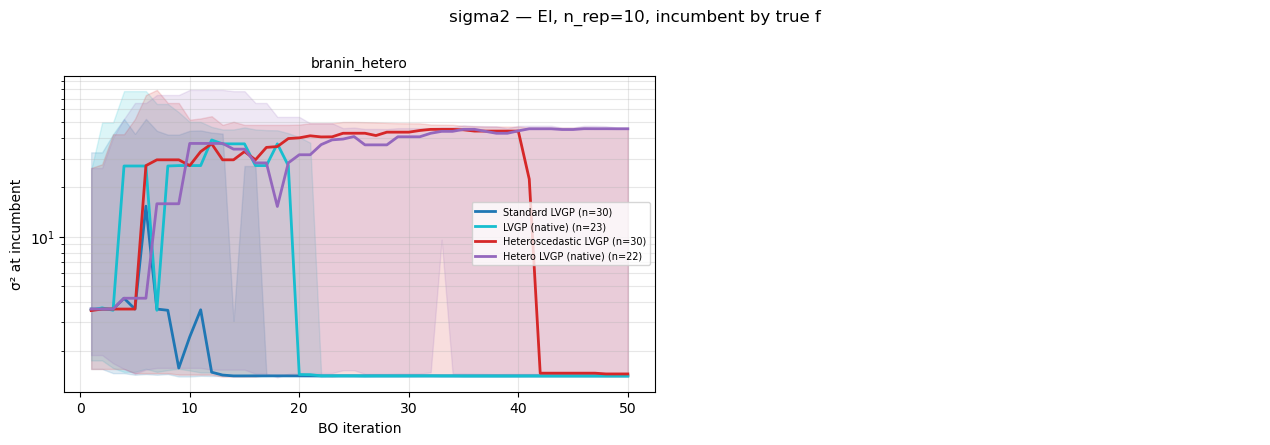

In [7]:
facet(grid, "sigma2", functions=[FUNC], acf="ei", n_rep=N_REP,
      ground_truth=GROUND_TRUTH, center=CENTER);

## 6. Per-acquisition convergence — one panel per acquisition, 4 models overlaid

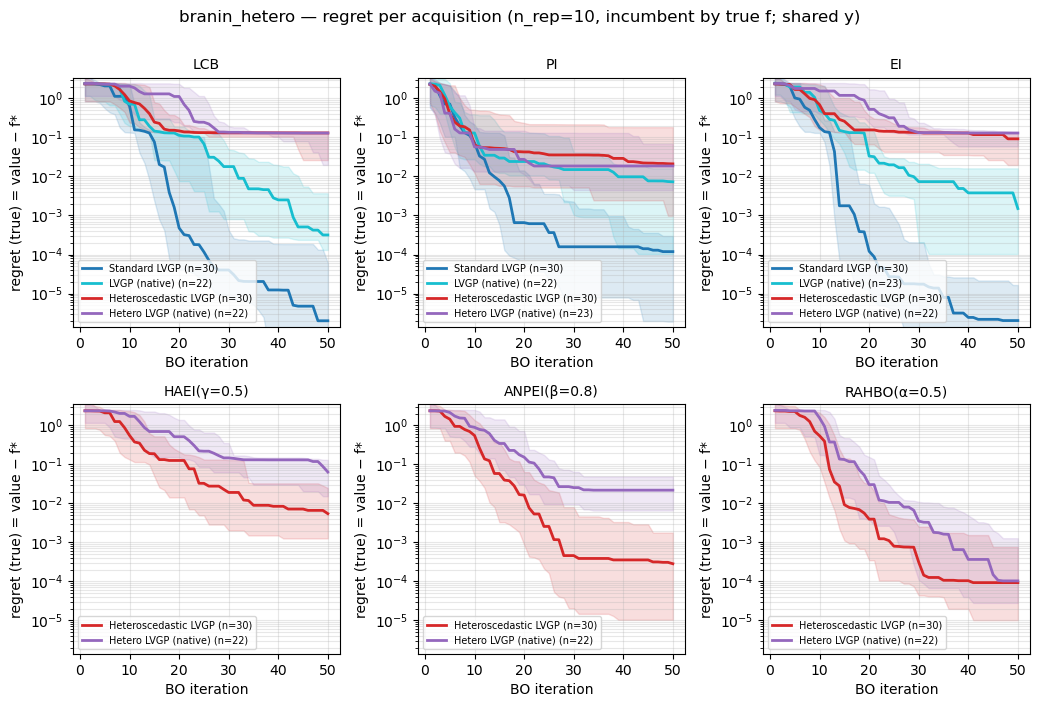

In [8]:
acquisition_facet(grid, FUNC, models=LVGP4, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, center=CENTER);

## 7. Coverage — how each engine samples the mixed space
Left: mean fraction of samples at each categorical level (optimum = level 2). Right: spread of the
x-locations sampled *within* the optimal level — larger = more exploration.

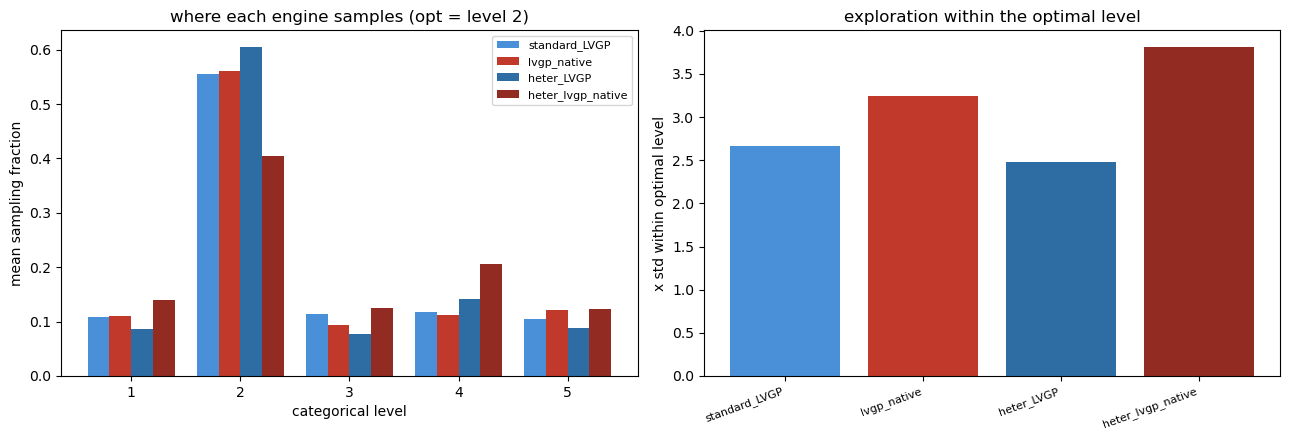

In [9]:
def _load_any(f):
    if f.endswith(".mat"): return sio.loadmat(f, simplify_cells=True)
    with np.load(f, allow_pickle=True) as z: return {k: z[k] for k in z.files}
def _cells_for(model, acq, nrep):
    base = f"../results/{FUNC}/{model}"
    if not os.path.isdir(base): return {}
    out = {}
    for d in [d for d in os.listdir(base) if d == acq or d.startswith(acq + "_")]:
        for f in glob.glob(f"{base}/{d}/nrep{nrep:02d}/seed*"):
            if f.endswith((".npz", ".mat")):
                c = _load_any(f); mt = c["meta"]
                sd = int((mt.item() if hasattr(mt, 'item') and mt.shape == () else mt)["seed"])
                out[sd] = c
    return out
NLV, OPT = 5, 2
ACQS = ["ei", "lcb", "pi", "haei", "anpei", "rahbo"]
PAIRS = [("standard_LVGP", "lvgp_native", ["ei", "lcb", "pi"]),
         ("heter_LVGP", "heter_lvgp_native", ACQS)]
frac, spread = {}, {}
for mlab, pnat, acqs in PAIRS:
    for model in (mlab, pnat):
        fr = np.zeros(NLV); xs = []; n = 0
        for acq in acqs:
            for sd, c in _cells_for(model, acq, N_REP).items():
                X = np.asarray(c["X_sampled"], float); lv = X[:, -1].astype(int)
                for L in range(1, NLV + 1): fr[L - 1] += np.mean(lv == L)
                xo = X[lv == OPT, 0]
                if len(xo) > 1: xs.append(xo.std())
                n += 1
        if n: frac[model] = fr / n; spread[model] = np.mean(xs) if xs else np.nan
present = [m for m in LVGP4 if m in frac]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
w = 0.8 / len(present)
cmap = {"standard_LVGP": "#4a90d9", "heter_LVGP": "#2e6da4", "lvgp_native": "#c0392b", "heter_lvgp_native": "#922b21"}
for i, m in enumerate(present):
    axL.bar(np.arange(1, NLV + 1) + (i - len(present) / 2 + 0.5) * w, frac[m], w, label=m, color=cmap.get(m))
axL.set_xlabel("categorical level"); axL.set_ylabel("mean sampling fraction")
axL.set_title(f"where each engine samples (opt = level {OPT})"); axL.set_xticks(range(1, NLV + 1)); axL.legend(fontsize=8)
axR.bar(range(len(present)), [spread[m] for m in present], color=[cmap.get(m) for m in present])
axR.set_xticks(range(len(present))); axR.set_xticklabels(present, rotation=20, ha="right", fontsize=8)
axR.set_ylabel("x std within optimal level"); axR.set_title("exploration within the optimal level")
plt.tight_layout(); plt.show()

## 8. Latent embedding — MATLAB vs Python
Learned 2-D latent coordinates for the 5 levels (heteroscedastic model). Same gauge on both engines
(level 1 at origin, level 2 on z1-axis), so maps are directly comparable up to a z2 reflection
(aligned). MATLAB `z` is read from the stored fit; Python `z` is recovered by refitting the native
model on the matched cell. **Look for the same structure** — which levels cluster.

per-level |z_python - z_matlab|: {'lv1': np.float64(0.0), 'lv2': np.float64(0.325), 'lv3': np.float64(0.164), 'lv4': np.float64(0.311), 'lv5': np.float64(0.133)}


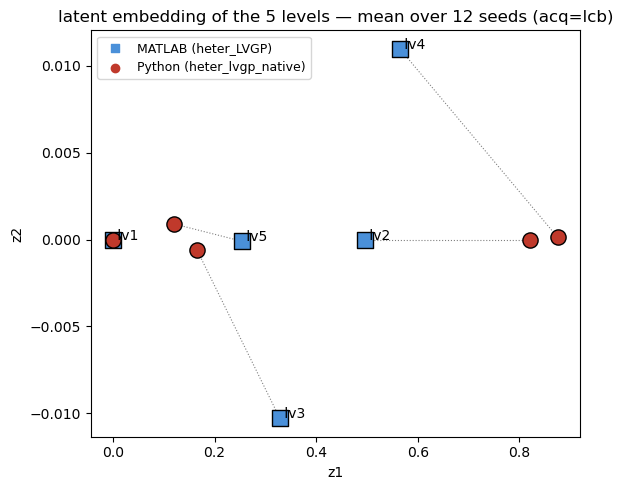

In [10]:
from utils.models.hetero_lvgp_native import HeterLVGPNative, _z_matrix
def _native_z(c):
    X = np.asarray(c["X_sampled"], float); y = np.asarray(c["Y_sampled"], float).ravel()
    v = np.asarray(c["Y_var_sampled"], float).ravel(); data = {}
    for lv in range(1, NLV + 1):
        m = X[:, -1].astype(int) == lv
        if m.sum(): data[lv] = {"X": X[m, :-1], "y_mean": y[m], "y_var": v[m]}
    mdl = HeterLVGPNative.fit(data, needs_r=False, bounds=P.get(FUNC).bounds)
    return _z_matrix(mdl._f["zf"], mdl._f["n_lvs"])
def _matlab_z(c):
    h = c["hyper"]; h = h.item() if hasattr(h, 'item') and getattr(h, 'shape', None) == () else h
    return np.asarray(h["z"], float).reshape(NLV, 2)
def _align(zn, zm):
    best, bz = None, zn
    for s in (1., -1.):
        z = zn.copy(); z[:, 1] *= s; e = np.sqrt(((z - zm) ** 2).sum(1)).mean()
        if best is None or e < best: best, bz = e, z
    return bz
ACQ_L, NSEED = "lcb", 12
Mm = _cells_for("heter_LVGP", ACQ_L, N_REP); Nn = _cells_for("heter_lvgp_native", ACQ_L, N_REP)
seeds = sorted(set(Mm) & set(Nn))[:NSEED]
zn, zm = [], []
for sd in seeds:
    try: zn.append(_align(_native_z(Nn[sd]), _matlab_z(Mm[sd]))); zm.append(_matlab_z(Mm[sd]))
    except Exception: pass
zn = np.mean(zn, 0); zm = np.mean(zm, 0)
fig, ax = plt.subplots(figsize=(6, 5))
for L in range(NLV):
    ax.scatter(*zm[L], c="#4a90d9", marker="s", s=120, edgecolor="k", zorder=3)
    ax.scatter(*zn[L], c="#c0392b", marker="o", s=120, edgecolor="k", zorder=3)
    ax.plot([zm[L, 0], zn[L, 0]], [zm[L, 1], zn[L, 1]], color="gray", lw=0.8, ls=":", zorder=1)
    ax.annotate(f" lv{L+1}", (zm[L, 0], zm[L, 1]), fontsize=10)
ax.scatter([], [], c="#4a90d9", marker="s", label="MATLAB (heter_LVGP)")
ax.scatter([], [], c="#c0392b", marker="o", label="Python (heter_lvgp_native)")
ax.set_xlabel("z1"); ax.set_ylabel("z2"); ax.legend(fontsize=9)
ax.set_title(f"latent embedding of the 5 levels — mean over {len(seeds)} seeds (acq={ACQ_L})")
perlv = np.sqrt(((zn - zm) ** 2).sum(1))
print("per-level |z_python - z_matlab|:", {f"lv{L+1}": round(perlv[L], 3) for L in range(NLV)})
plt.tight_layout(); plt.show()

## 9. Summary heatmaps — acquisition × model (regret), MATLAB vs Python side by side

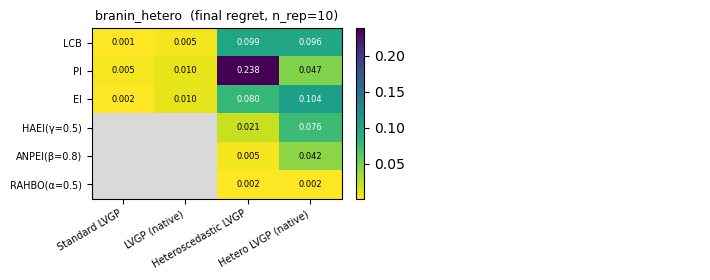

In [11]:
heatmaps_by_function(grid, functions=[FUNC], n_rep=N_REP, ground_truth=GROUND_TRUTH);